In [1]:
!pip install yfinance

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf  # Tambahkan baris ini


In [6]:
df = yf.download('BTC-USD', start='2023-01-01', end='2026-09-01')


/tmp/ipykernel_1763/311457838.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download('BTC-USD', start='2023-01-01', end='2026-09-01')
[*********************100%***********************]  1 of 1 completed


In [7]:
df = yf.download('BTC-USD', start='2023-01-01', end='2026-09-01')


/tmp/ipykernel_1763/311457838.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download('BTC-USD', start='2023-01-01', end='2026-09-01')
[*********************100%***********************]  1 of 1 completed


In [24]:
# Add this in a new cell below the data acquisition step
df_features = df[['Close']].copy()

# 1. Add a 7-day Simple Moving Average (SMA)
df_features['SMA_7'] = df_features['Close'].rolling(window=7).mean()

# 2. Add a 14-day Relative Strength Index (RSI)
delta = df_features['Close'].diff()
gain = (delta.where(delta > 0, 0)).rolling(window=14).mean()
loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()
rs = gain / loss
df_features['RSI_14'] = 100 - (100 / (1 + rs))

# Create target variable and drop rows with empty values caused by indicators
df_features['Tomorrow_Price'] = df_features['Close'].shift(-1)
df_features.dropna(inplace=True)

print("Advanced features calculated successfully!")
df_features.head()


Advanced features calculated successfully!


Price,Close,SMA_7,RSI_14,Tomorrow_Price
Ticker,BTC-USD,,,
Date,,,,
2023-01-14,20976.298828,18489.192801,99.205798,20880.798828
2023-01-15,20880.798828,19030.571987,97.108331,21169.632812
2023-01-16,21169.632812,19598.154576,97.245795,21161.519531
2023-01-17,21161.519531,20128.901228,97.256048,20688.781250
2023-01-18,20688.781250,20522.313337,88.017818,21086.792969


In [8]:
print("--- Bitcoin Dataset Sample ---")
df.head()


--- Bitcoin Dataset Sample ---


Price,Close,High,Low,Open,Volume
Ticker,BTC-USD,BTC-USD,BTC-USD,BTC-USD,BTC-USD
Date,,,,,
2023-01-01,16625.080078,16630.439453,16521.234375,16547.914062,9244361700
2023-01-02,16688.470703,16759.343750,16572.228516,16625.509766,12097775227
2023-01-03,16679.857422,16760.447266,16622.371094,16688.847656,13903079207
2023-01-04,16863.238281,16964.585938,16667.763672,16680.205078,18421743322
2023-01-05,16836.736328,16884.021484,16790.283203,16863.472656,13692758566


In [9]:
df_clean = df[['Close']].copy()


In [10]:
df_clean['Tomorrow_Price'] = df_clean['Close'].shift(-1)


In [11]:
df_clean.dropna(inplace=True)
print("Data cleaning completed!")


Data cleaning completed!


In [25]:
# Change this cell to use your new advanced features
X = df_features[['Close', 'SMA_7', 'RSI_14']].values
y = df_features['Tomorrow_Price'].values
print("Multi-feature matrix X and target y are ready!")


Multi-feature matrix X and target y are ready!


In [26]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Training set: {X_train.shape[0]} days | Testing set: {X_test.shape[0]} days")


Training set: 1060 days | Testing set: 265 days


In [27]:
model = LinearRegression()
model.fit(X_train, y_train)
print("Machine Learning model training completed!")


Machine Learning model training completed!


In [28]:
y_pred = model.predict(X_test)
print("Prediction process complete.")


Prediction process complete.


In [29]:
accuracy_score = r2_score(y_test, y_pred)
print(f"Model Accuracy (R2 Score): {accuracy_score:.4f}")


Model Accuracy (R2 Score): 0.9966


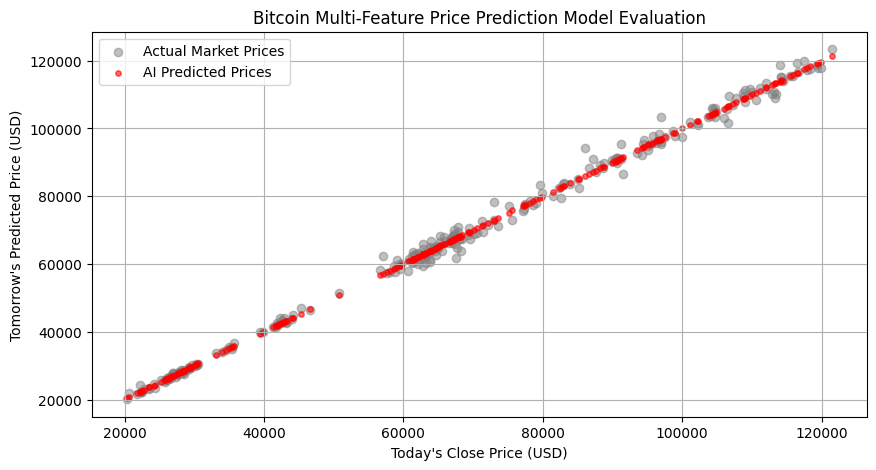

In [31]:
# Combine everything into one single cell
plt.figure(figsize=(10, 5))

# Use X_test[:, 0] to extract ONLY the 'Close' price column for the X-axis
plt.scatter(X_test[:, 0], y_test, color='gray', alpha=0.5, label='Actual Market Prices')
plt.scatter(X_test[:, 0], y_pred, color='red', alpha=0.6, s=15, label='AI Predicted Prices')

plt.title('Bitcoin Multi-Feature Price Prediction Model Evaluation')
plt.xlabel("Today's Close Price (USD)")
plt.ylabel("Tomorrow's Predicted Price (USD)")
plt.legend()
plt.grid(True)
plt.show()
